In [1]:
import torch

In [2]:
import torch.nn as nn

In [3]:
import torch.optim as optim

In [4]:
import torchvision

In [5]:
import torchvision.transforms as transforms

In [6]:
import matplotlib.pyplot as plt

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [8]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        
        # Gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)  # values between 0 and 1
        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [9]:
class PrunableNet(nn.Module):
    def __init__(self):
        super(PrunableNet, self).__init__()
        
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = PrunableLinear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        gates = []
        for layer in self.modules():
            if isinstance(layer, PrunableLinear):
                gates.append(layer.get_gates().view(-1))
        return torch.cat(gates)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)


# Training Function

def train_model(lambda_reg, epochs=5):
    model = PrunableNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            # Classification loss
            class_loss = criterion(outputs, labels)

            # Sparsity loss (L1 on gates)
            gates = model.get_all_gates()
            sparsity_loss = torch.sum(gates)

            loss = class_loss + lambda_reg * sparsity_loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Lambda {lambda_reg} | Epoch {epoch+1} | Loss: {total_loss:.3f}")

    return model

Lambda 1e-05 | Epoch 1 | Loss: 3751.885
Lambda 1e-05 | Epoch 2 | Loss: 3197.589
Lambda 1e-05 | Epoch 3 | Loss: 2768.772
Lambda 1e-05 | Epoch 4 | Loss: 2424.463
Lambda 1e-05 | Epoch 5 | Loss: 2150.651
Lambda=1e-05 | Accuracy=54.08% | Sparsity=0.04%
Lambda 0.0001 | Epoch 1 | Loss: 31355.670
Lambda 0.0001 | Epoch 2 | Loss: 26070.452
Lambda 0.0001 | Epoch 3 | Loss: 21270.521
Lambda 0.0001 | Epoch 4 | Loss: 17122.449
Lambda 0.0001 | Epoch 5 | Loss: 13718.075
Lambda=0.0001 | Accuracy=54.74% | Sparsity=0.07%
Lambda 0.001 | Epoch 1 | Loss: 307493.182
Lambda 0.001 | Epoch 2 | Loss: 255147.333
Lambda 0.001 | Epoch 3 | Loss: 206918.602
Lambda 0.001 | Epoch 4 | Loss: 164873.494
Lambda 0.001 | Epoch 5 | Loss: 130082.377
Lambda=0.001 | Accuracy=53.26% | Sparsity=0.08%


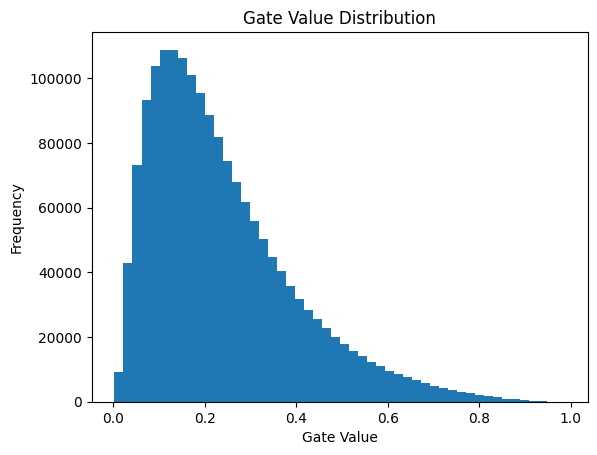


Final Results:
Lambda	Accuracy	Sparsity
1e-05	54.08		0.04
0.0001	54.74		0.07
0.001	53.26		0.08


In [ ]:
# Evaluation

def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    # Sparsity calculation
    gates = model.get_all_gates()
    threshold = 1e-2
    pruned = torch.sum(gates < threshold).item()
    total_gates = gates.numel()

    sparsity = 100 * pruned / total_gates

    return accuracy, sparsity, gates.detach().cpu().numpy()



lambdas = [1e-5, 1e-4, 1e-3]
results = []

best_gates = None

for lam in lambdas:
    model = train_model(lam)
    acc, sparsity, gates = evaluate(model)

    results.append((lam, acc, sparsity))
    print(f"Lambda={lam} | Accuracy={acc:.2f}% | Sparsity={sparsity:.2f}%")

    if best_gates is None or acc > max(r[1] for r in results):
        best_gates = gates



plt.hist(best_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()



print("\nFinal Results:")
print("Lambda\tAccuracy\tSparsity")
for r in results:
    print(f"{r[0]}\t{r[1]:.2f}\t\t{r[2]:.2f}")